<a href="https://colab.research.google.com/github/RidhoAnfaal/PCVK_Ganjil_2025/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

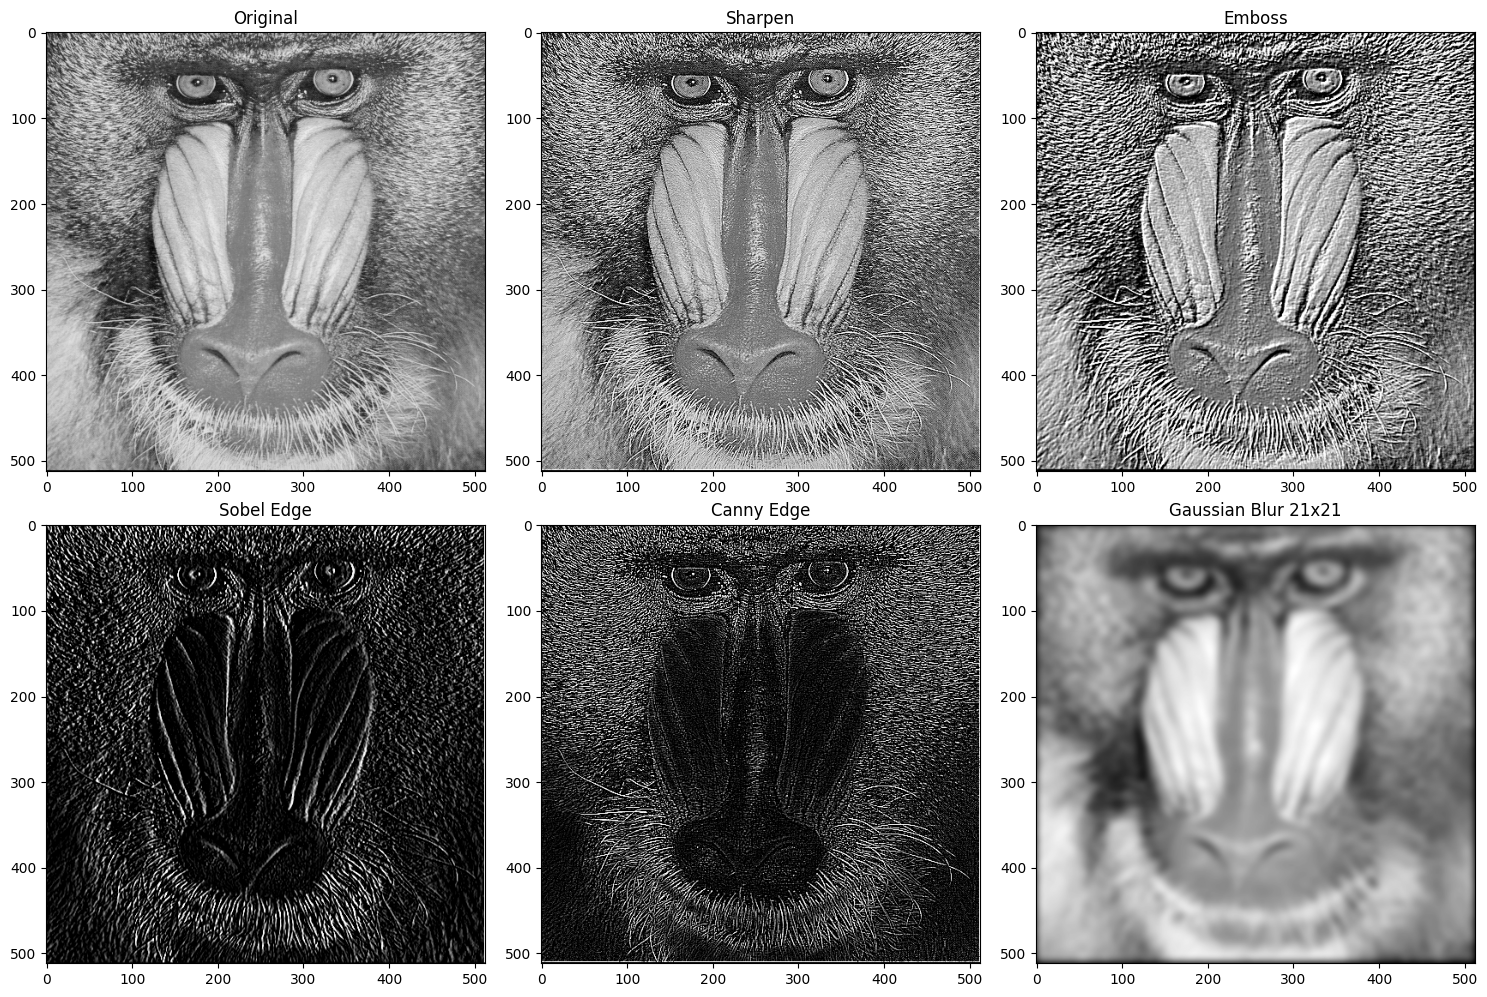

In [13]:
def convolution2d(image, kernel, stride, padding):
    h, w = image.shape
    kh, kw = kernel.shape

    padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
    output_h = (h - kh + 2*padding) // stride + 1
    output_w = (w - kw + 2*padding) // stride + 1

    output = np.zeros((output_h, output_w), dtype=np.float32)

    for y in range(output_h):
        for x in range(output_w):
            region = padded[y*stride:y*stride+kh, x*stride:x*stride+kw]
            output[y, x] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

img = cv.imread('/content/gdrive/MyDrive/PCVK/mandrill.tiff', cv.IMREAD_GRAYSCALE)

kernel_size = 21
sigma = math.sqrt(kernel_size)
gk = cv.getGaussianKernel(kernel_size, sigma)
gaussian_kernel = gk @ gk.T

kernels = {
    "Sharpen": np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]]),

    "Emboss": np.array([[-2, -1, 0],
                        [-1,  1, 1],
                        [ 0,  1, 2]]),

    "Sobel Edge": np.array([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]]),

    "Canny Edge": np.array([[-1, -1, -1],
                            [-1,  8, -1],
                            [-1, -1, -1]]),

    "Gaussian Blur 21x21": gaussian_kernel
}

results = {}
for name, kernel in kernels.items():
    pad = kernel.shape[0] // 2
    results[name] = convolution2d(img, kernel, stride=1, padding=pad)

plt.figure(figsize=(15,10))
plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

for i, (name, result) in enumerate(results.items(), 2):
    plt.subplot(2,3,i)
    plt.imshow(result, cmap='gray')
    plt.title(name)

plt.tight_layout()
plt.show()

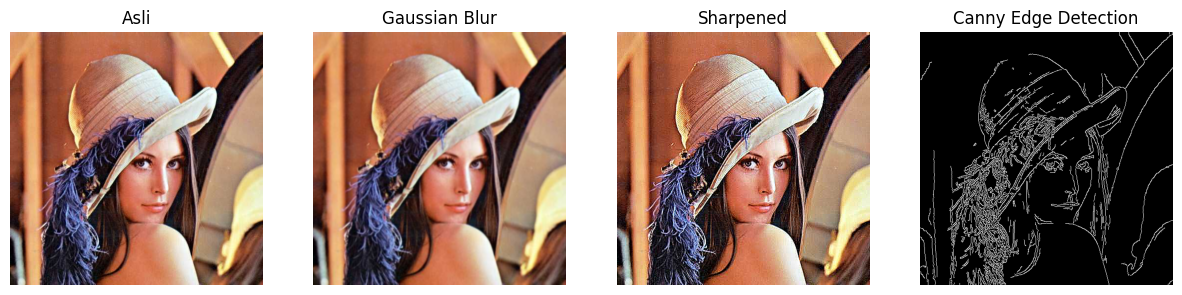

In [14]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate (zip(images, titles)):
    if len(img.shape) == 2: # grayscale
      plt.subplot(1, len(images), i+1)
      plt.imshow(img, cmap="gray")
    else: # color
      plt.subplot(1, len(images), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
  plt.show()

img = cv.imread("/content/gdrive/MyDrive/PCVK/lena.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges], ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

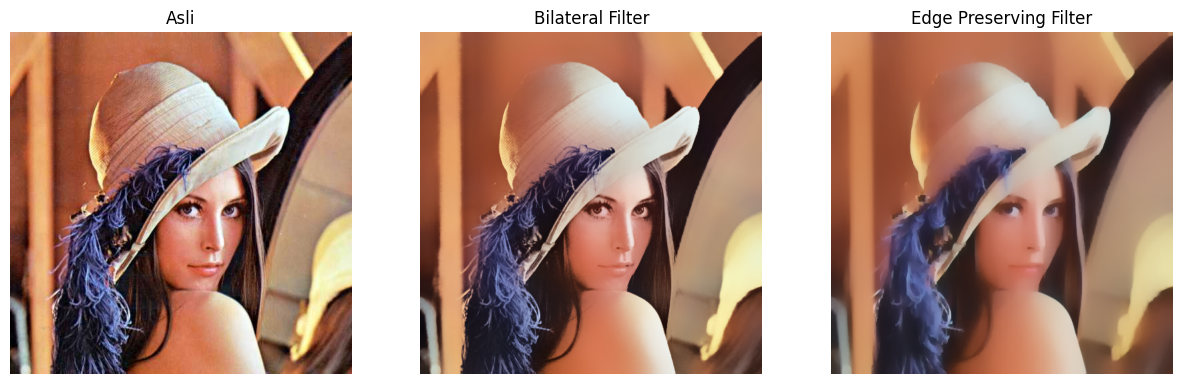

In [16]:
#Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter (img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)
show_side_by_side([img, bilateral, edge_preserve], ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

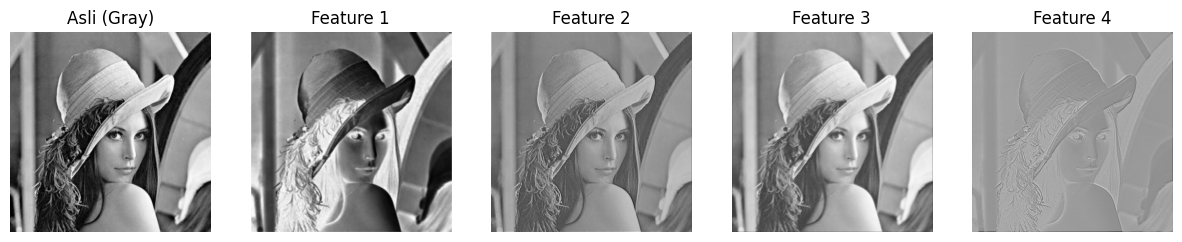

In [33]:
#Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

  def forward(self, x):
     return self.conv1(x)


model = SimpleCNN()

#Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze (0).unsqueeze (0) / 255.0

#Hasil CNN
with torch.no_grad():
  features = model(img_tensor)

#Visualisasi feature maps
feature_maps = [features [0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

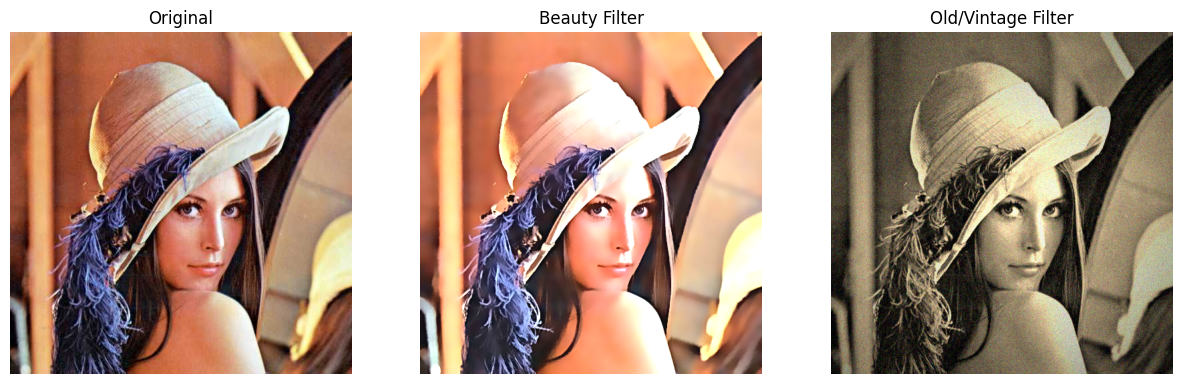

In [36]:
# ======================
# 1. Beauty Filter
# ======================
# Step 1: Smooth skin using bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (enhance edges like eyes/lips)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# ======================
# 2. Old/Vintage Filter
# ======================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side(
    [img, beauty, old_img],
    ["Original", "Beauty Filter", "Old/Vintage Filter"]
)

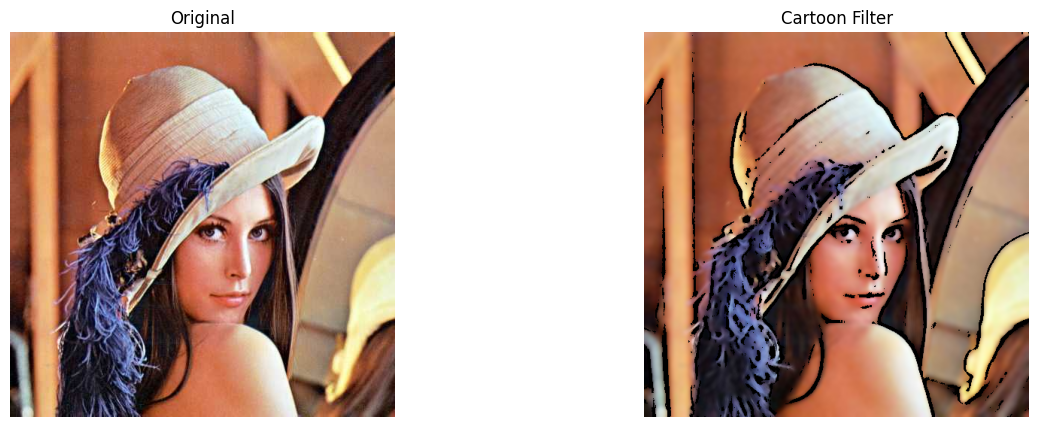

In [35]:
# Filter Anime / Cartoon
# Step 1: Edge detection (use median blur for smoother edges)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter for color smoothing
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Combine edges with smoothed color (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Show result
show_side_by_side([img, cartoon], ["Original", "Cartoon Filter"])

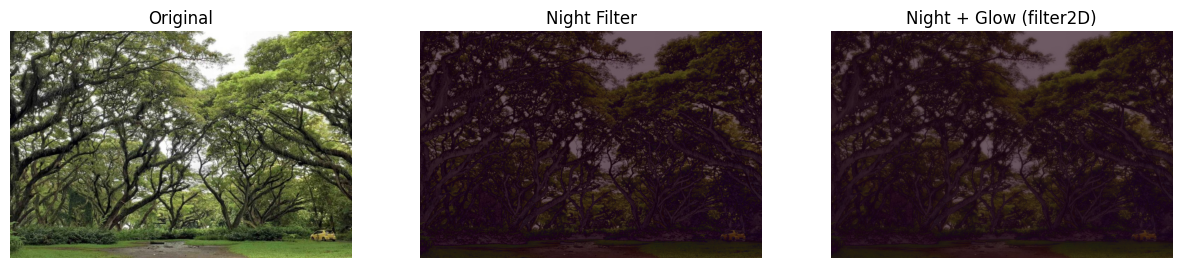

In [37]:
# Night Filter
img = cv.imread("/content/gdrive/MyDrive/PCVK/djawatan.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Darken (decrease contrast, negative brightness)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Add blue bias
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Glow effect in bright areas with 2D filters (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Combine original + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow], ["Original", "Night Filter", "Night + Glow (filter2D)"])

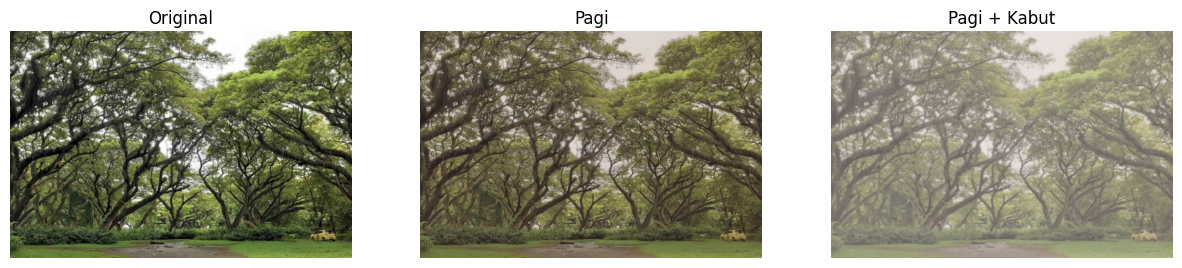

In [39]:

# Morning and Fog Filter
# =============================
# Step 1: Reduce contrast & brighten
# =============================
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =============================
# Step 2: Add warm tone (reddish / orange)
# =============================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =============================
# Step 3: Add haze (thin fog) with filter2D
# =============================
# Gaussian-like kernel blur to create a haze effect
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # make it a 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# add a white layer to make the haze more realistic
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut], ["Original", "Pagi", "Pagi + Kabut"])